In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/validation/Ebola/6132.tif
/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/validation/Ebola/6144.tif
/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/validation/Ebola/6133.tif
/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/validation/Ebola/2578.tif
/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/validation/Ebola/2564.tif
/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/validation/Ebola/1514.tif
/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/validation/Ebola/6151.tif
/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/validation/Ebola/6139.tif
/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/validation/Ebola/2574.tif
/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/validation/Ebola/6159.tif
/kaggle/input/datasets/saurabhshahane/virus-images

In [2]:
!pip install timm torchmetrics transformers -q

In [3]:
import os, gc, copy, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
import tifffile as tiff
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import timm
from collections import Counter
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, top_k_accuracy_score
)
from sklearn.preprocessing import label_binarize
warnings.filterwarnings("ignore")

# Speed flags
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True

## 1 · Config

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES     = 22
DET_NUM_CLASSES = 23   # 22 virus classes + background
TRAIN_ROOT = "/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/train"
VAL_ROOT   = "/kaggle/input/datasets/saurabhshahane/virus-images/context_virus_RAW/validation"
RESULTS    = "results/hybrid_multi"
os.makedirs(RESULTS, exist_ok=True)

if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("CPU only")

# Classifier weights (from your earlier training — normalised)
MODEL_WEIGHTS = {
    "ResNet50": 0.661290,
    "DenseNet121": 0.802419,
    "EfficientNetV2": 0.798387,
    "ConvNeXt": 0.854839,
    "ViT": 0.842742,
    "Swin": 0.899194,
    "DeiT": 0.866935,
    "MaxViT": 0.887097,
}
total = sum(MODEL_WEIGHTS.values())
MODEL_WEIGHTS = {k: v/total for k, v in MODEL_WEIGHTS.items()}

GPU : Tesla T4
VRAM: 15.6 GB


## 2 · Datasets

In [5]:
# ── Classification dataset ──────────────────────────────────────────
class VirusClassificationDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir)
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples = []
        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            for f in os.listdir(cls_path):
                if f.endswith(".tif"):
                    self.samples.append((os.path.join(cls_path, f),
                                         self.class_to_idx[cls]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = tiff.imread(path)
        img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
        img = Image.fromarray(img).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label


# ── Detection dataset ────────────────────────────────────────────────
class VirusDetectionDataset(Dataset):
    def __init__(self, root_dir, box_size=64):
        from torchvision.transforms import functional as TVF
        self._tvf = TVF
        self.box_size = box_size
        self.classes = sorted([d for d in os.listdir(root_dir)
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {c: i+1 for i, c in enumerate(self.classes)}
        self.samples = [
            (cls, os.path.join(root_dir, cls, f))
            for cls in self.classes
            for f in os.listdir(os.path.join(root_dir, cls))
            if f.endswith(".tif")
        ]
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        cls, path = self.samples[idx]
        label = self.class_to_idx[cls]
        img = tiff.imread(path)
        img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
        img = self._tvf.to_tensor(Image.fromarray(img).convert("RGB"))
        h, w = img.shape[1:]

        name = os.path.splitext(os.path.basename(path))[0]
        txt  = os.path.join(os.path.dirname(path),
                            "particle_positions",
                            name + "_particlepositions.txt")
        boxes = []
        if os.path.exists(txt):
            for line in open(txt):
                line = line.strip()
                if ";" not in line: continue
                parts = line.split(";")
                if len(parts) != 2: continue
                try:
                    x, y = int(float(parts[0])), int(float(parts[1]))
                    x1 = max(0, x - self.box_size//2)
                    y1 = max(0, y - self.box_size//2)
                    x2 = min(w, x + self.box_size//2)
                    y2 = min(h, y + self.box_size//2)
                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])
                except: continue

        boxes = (torch.as_tensor(boxes, dtype=torch.float32)
                 if boxes else torch.zeros((0,4), dtype=torch.float32))

        # Safe flip augmentation
        if random.random() > 0.5:
            img = torch.flip(img, [2])
            if len(boxes): boxes[:,[0,2]] = w - boxes[:,[2,0]]
        if random.random() > 0.5:
            img = torch.flip(img, [1])
            if len(boxes): boxes[:,[1,3]] = h - boxes[:,[3,1]]

        return img, {"boxes": boxes,
                     "labels": torch.full((len(boxes),), label, dtype=torch.int64)}

def collate_det(batch): return tuple(zip(*batch))

## 3 · Transforms & DataLoaders

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

train_cls_ds = VirusClassificationDataset(TRAIN_ROOT, train_transform)
val_cls_ds   = VirusClassificationDataset(VAL_ROOT,   val_transform)
class_names  = train_cls_ds.classes
print(f"Classes ({len(class_names)}): {class_names}")

train_cls_loader = DataLoader(train_cls_ds, batch_size=16, shuffle=True,
                               num_workers=2, pin_memory=True)
val_cls_loader   = DataLoader(val_cls_ds,   batch_size=16, shuffle=False,
                               num_workers=2, pin_memory=True)

train_det_ds = VirusDetectionDataset(TRAIN_ROOT)
val_det_ds   = VirusDetectionDataset(VAL_ROOT)
train_det_loader = DataLoader(train_det_ds, batch_size=4, shuffle=True,
                               collate_fn=collate_det, num_workers=2)
val_det_loader   = DataLoader(val_det_ds,   batch_size=4, shuffle=False,
                               collate_fn=collate_det, num_workers=2)

# Class-imbalance weights for cross-entropy
counts  = Counter(l for _, l in train_cls_ds.samples)
weights = torch.tensor([1.0/counts[i] for i in range(NUM_CLASSES)])
weights = (weights / weights.sum() * NUM_CLASSES).to(device)
print("Dataloaders ready.")

Classes (22): ['Adenovirus', 'Astrovirus', 'CCHF', 'Cowpox', 'Dengue', 'Ebola', 'Guanarito', 'Influenza', 'LCM', 'Lassa', 'Machupo', 'Marburg', 'Nipah virus', 'Norovirus', 'Orf', 'Papilloma', 'Pseudocowpox', 'Rift Valley', 'Rotavirus', 'Sapovirus', 'TBE', 'WestNile']
Dataloaders ready.


## 4 · Classifier Models  (4 CNN + 4 Transformer)

In [7]:
CLS_MODELS = {
    # ── CNN ────────────────────────────────────────────────────────────
    "ResNet50":        "resnet50",
    "EfficientNetV2":  "tf_efficientnetv2_s",
    "ConvNeXt":        "convnext_small",
    "DenseNet121":     "densenet121",
    # ── Transformer ────────────────────────────────────────────────────
    "ViT":             "vit_base_patch16_224",
    "Swin":            "swin_small_patch4_window7_224",
    "DeiT":            "deit_base_patch16_224",
    "MaxViT":          "maxvit_tiny_tf_224",
}

def make_classifier(name):
    return timm.create_model(CLS_MODELS[name], pretrained=True,
                              num_classes=NUM_CLASSES)

## 5 · Train Classifiers  (one at a time — memory safe)

In [8]:
def train_classifier(name, epochs=15):
    model = make_classifier(name).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler    = torch.cuda.amp.GradScaler()
    best_f1, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        for imgs, labels in tqdm(train_cls_loader, desc=f"{name} [{epoch+1}/{epochs}]",
                                  leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                loss = criterion(model(imgs), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
        scheduler.step()

        # Validation F1
        model.eval(); preds, trues = [], []
        with torch.inference_mode():
            for imgs, labels in val_cls_loader:
                preds += model(imgs.to(device)).argmax(1).cpu().tolist()
                trues += labels.tolist()
        f1 = f1_score(trues, preds, average="macro", zero_division=0)
        print(f"  {name}  epoch {epoch+1:02d}/{epochs}  val-F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    torch.save(best_state, f"{name}_best.pth")
    print(f"✅  {name}  saved  (best F1 = {best_f1:.4f})")
    del model; torch.cuda.empty_cache(); gc.collect()


for name in CLS_MODELS:
    path = f"{name}_best.pth"
    if not os.path.exists(path):
        train_classifier(name)
    else:
        print(f"⏭   {name}  already trained")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

  ResNet50  epoch 01/15  val-F1: 0.0387


  ResNet50  epoch 02/15  val-F1: 0.1458


  ResNet50  epoch 03/15  val-F1: 0.1779


  ResNet50  epoch 04/15  val-F1: 0.2378


...

  MaxViT  epoch 11/15  val-F1: 0.8444


  MaxViT  epoch 12/15  val-F1: 0.8343


  MaxViT  epoch 13/15  val-F1: 0.8242


  MaxViT  epoch 14/15  val-F1: 0.8443


  MaxViT  epoch 15/15  val-F1: 0.8417
✅  MaxViT  saved  (best F1 = 0.8444)


## 6 · Detection Models  (Faster R-CNN · RetinaNet · FCOS · DETR)

In [9]:
# ── Faster R-CNN ────────────────────────────────────────────────────
def make_faster_rcnn():
    m = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_f = m.roi_heads.box_predictor.cls_score.in_features
    m.roi_heads.box_predictor = \
        torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_f, DET_NUM_CLASSES)
    return m

# ── RetinaNet ────────────────────────────────────────────────────────
def make_retinanet():
    m = torchvision.models.detection.retinanet_resnet50_fpn(weights="DEFAULT")
    in_ch  = m.head.classification_head.cls_logits.in_channels
    n_anch = m.head.classification_head.num_anchors
    m.head.classification_head = \
        torchvision.models.detection.retinanet.RetinaNetClassificationHead(
            in_ch, n_anch, DET_NUM_CLASSES)
    return m

# ── FCOS ─────────────────────────────────────────────────────────────
def make_fcos():
    m = torchvision.models.detection.fcos_resnet50_fpn(weights="DEFAULT")
    in_ch  = m.head.classification_head.cls_logits.in_channels
    n_anch = m.head.classification_head.num_anchors
    m.head.classification_head = \
        torchvision.models.detection.fcos.FCOSClassificationHead(
            in_ch, n_anch, DET_NUM_CLASSES)
    return m

# ── DETR (HuggingFace — Transformer-based detector) ──────────────────
class DETRDetector(nn.Module):
    """Wraps facebook/detr-resnet-50 with a torchvision-compatible interface."""
    TARGET_SIZE = (800, 800)

    def __init__(self, score_thresh=0.5):
        super().__init__()
        from transformers import DetrForObjectDetection
        self.core = DetrForObjectDetection.from_pretrained(
            "facebook/detr-resnet-50",
            num_labels=NUM_CLASSES,
            ignore_mismatched_sizes=True
        )
        self.score_thresh = score_thresh

    def _resize(self, img):
        return F.interpolate(
            img.unsqueeze(0).float(),   # always fp32
            size=self.TARGET_SIZE,
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

    def forward(self, images, targets=None):
        orig_sizes   = [img.shape[1:] for img in images]
        pixel_values = torch.stack([self._resize(img) for img in images])  # fp32

        if self.training and targets is not None:
            hf_targets = []
            for orig_hw, t in zip(orig_sizes, targets):
                H, W  = orig_hw
                boxes = t["boxes"].float()   # ensure fp32
                if len(boxes):
                    cx = (boxes[:,0] + boxes[:,2]) / (2.0 * W)
                    cy = (boxes[:,1] + boxes[:,3]) / (2.0 * H)
                    bw = (boxes[:,2] - boxes[:,0]) / W
                    bh = (boxes[:,3] - boxes[:,1]) / H
                    norm_boxes = torch.stack([cx, cy, bw, bh], 1).clamp(0, 1)
                else:
                    norm_boxes = torch.zeros((0, 4), device=boxes.device)
                hf_targets.append({
                    "class_labels": (t["labels"] - 1).clamp(min=0),
                    "boxes":        norm_boxes
                })

            # ← DETR must run in fp32; AMP fp16 produces NaN in the matcher
            with torch.cuda.amp.autocast(enabled=False):
                out = self.core(pixel_values=pixel_values, labels=hf_targets)
            return {"loss_detr": out.loss}

        else:
            with torch.cuda.amp.autocast(enabled=False):
                out = self.core(pixel_values=pixel_values)
            results = []
            for i, orig_hw in enumerate(orig_sizes):
                H, W       = orig_hw
                logits     = out.logits[i]
                pred_boxes = out.pred_boxes[i]
                probs      = torch.softmax(logits.float(), -1)
                scores, labels = probs[:, :-1].max(-1)
                keep = scores > self.score_thresh
                if keep.any():
                    b  = pred_boxes[keep].float()
                    x1 = (b[:,0] - b[:,2]/2) * W
                    y1 = (b[:,1] - b[:,3]/2) * H
                    x2 = (b[:,0] + b[:,2]/2) * W
                    y2 = (b[:,1] + b[:,3]/2) * H
                    abs_boxes = torch.stack([x1, y1, x2, y2], 1)
                else:
                    abs_boxes = torch.zeros((0, 4), device=pixel_values.device)
                results.append({
                    "boxes":  abs_boxes,
                    "labels": labels[keep] + 1,
                    "scores": scores[keep]
                })
            return results

DET_FACTORIES = {
    "FasterRCNN": make_faster_rcnn,
    "RetinaNet":  make_retinanet,
    "FCOS":       make_fcos,
    "DETR":       DETRDetector,
}
print("Detector factories defined.")

Detector factories defined.


## 7 · Train Detectors  (one at a time — memory safe, AMP)

In [10]:
def train_detector(model, name, epochs=10):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

    # DETR must stay in fp32 — its Hungarian matcher produces NaN under fp16
    use_amp = (name != "DETR")
    scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_loss = float("inf")

    for epoch in range(epochs):
        model.train(); total = 0
        for imgs, tgts in tqdm(train_det_loader, desc=f"{name} [{epoch+1}/{epochs}]",
                                leave=False):
            imgs = [i.to(device) for i in imgs]
            tgts = [{k: v.to(device) for k, v in t.items()} for t in tgts]
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                loss_dict = model(imgs, tgts)
                loss      = sum(loss_dict.values())

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            total += loss.item()

        scheduler.step()
        avg = total / len(train_det_loader)
        print(f"  {name}  epoch {epoch+1:02d}/{epochs}  loss: {avg:.4f}")
        if avg < best_loss:
            best_loss = avg
            torch.save(model.state_dict(), f"{name}_det_best.pth")

    model.cpu(); torch.cuda.empty_cache(); gc.collect()
    print(f"✅  {name}  saved  (best loss = {best_loss:.4f})")


for det_name, factory in DET_FACTORIES.items():
    path = f"{det_name}_det_best.pth"
    if not os.path.exists(path):
        m = factory()
        train_detector(m, det_name, epochs=10)
        del m; torch.cuda.empty_cache(); gc.collect()
    else:
        print(f"⏭   {det_name}  already trained")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 194MB/s]  


  FasterRCNN  epoch 01/10  loss: 0.9990


  FasterRCNN  epoch 02/10  loss: 0.7254


  FasterRCNN  epoch 03/10  loss: 0.6624


...

  DETR  epoch 06/10  loss: 3.5520


  DETR  epoch 07/10  loss: 3.5041


  DETR  epoch 08/10  loss: 3.4988


  DETR  epoch 09/10  loss: 3.4016


  DETR  epoch 10/10  loss: 3.3496
✅  DETR  saved  (best loss = 3.3496)


## 8 · Load All Trained Models

In [11]:
# ── Classifiers in fp16 (halves VRAM usage) ─────────────────────────
print("Loading classifiers (fp16)…")
classifiers = {}
for name in CLS_MODELS:
    m = make_classifier(name)
    m.load_state_dict(torch.load(f"{name}_best.pth", map_location=device))
    classifiers[name] = m.to(device).half().eval()
print(f"  {len(classifiers)} classifiers loaded  ✓")

# ── Detectors in fp32 ────────────────────────────────────────────────
print("Loading detectors (fp32)…")
detectors = {}
for det_name, factory in DET_FACTORIES.items():
    m = factory()
    m.load_state_dict(torch.load(f"{det_name}_det_best.pth", map_location=device))
    detectors[det_name] = m.to(device).eval()
print(f"  {len(detectors)} detectors loaded  ✓")

used = torch.cuda.memory_allocated() / 1e9
total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"  GPU: {used:.2f} / {total_vram:.1f} GB used")

Loading classifiers (fp16)…
  8 classifiers loaded  ✓
Loading detectors (fp32)…


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |                                                                                       
----------------------------------------------------------------------------+------------+---------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                       
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                       
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                       
model.backbone.conv_encoder.model.layer4.0.do

  4 detectors loaded  ✓
  GPU: 1.36 / 15.6 GB used


## 9 · Hybrid Multi-Detector Inference Functions

In [12]:
# ── Cell: Fixed Hybrid Inference Functions ───────────────────────────────────

@torch.inference_mode()
def get_fused_crops(image_tensor, detectors, score_thresh=0.5, nms_iou=0.5):
    """
    Run all 4 detectors, fuse boxes with NMS.
    Returns fused boxes (as tensors) and mean detection confidence score.
    """
    all_boxes, all_scores = [], []
    img_gpu = image_tensor.to(device)

    for det in detectors.values():
        out    = det([img_gpu])
        boxes  = out[0]["boxes"]
        scores = out[0]["scores"]
        keep   = scores > score_thresh
        if keep.any():
            all_boxes.append(boxes[keep].cpu())
            all_scores.append(scores[keep].cpu())

    if not all_boxes:
        return [], 0.0

    all_boxes_t  = torch.cat(all_boxes).float()
    all_scores_t = torch.cat(all_scores).float()
    keep_idx     = torchvision.ops.nms(all_boxes_t, all_scores_t, nms_iou)

    fused_boxes  = all_boxes_t[keep_idx]
    # Mean detection confidence — used later to gate the detection signal
    det_confidence = all_scores_t[keep_idx].mean().item()

    return fused_boxes, det_confidence


@torch.inference_mode()
def full_image_ensemble(image_tensor, classifiers, model_weights, device):
    """
    Weighted ensemble of all 8 classifiers on the full image.
    This is the primary classification signal (trained domain).
    Returns prob tensor (1, 22).
    """
    img_fp16 = (F.interpolate(image_tensor.unsqueeze(0).to(device),
                               size=(224, 224))
                 .half())
    w_sum = None
    for name, model in classifiers.items():
        probs = torch.softmax(model(img_fp16).float(), dim=1)
        w     = model_weights[name]
        w_sum = w * probs if w_sum is None else w_sum + w * probs
    return w_sum   # (1, 22)


@torch.inference_mode()
def detection_vote_probs(fused_boxes, image_tensor, classifiers,
                          model_weights, device, num_classes=22):
    """
    For each detected crop, run the full-image ensemble ON THAT CROP.
    Returns averaged crop-level prob tensor (1, 22).
    Only called when detections exist.
    """
    valid_crops = []
    for box in fused_boxes:
        x1, y1, x2, y2 = box.int().tolist()
        x1 = max(0, x1); y1 = max(0, y1)
        x2 = max(x1 + 10, x2); y2 = max(y1 + 10, y2)
        crop = image_tensor[:, y1:y2, x1:x2]
        if crop.shape[1] >= 10 and crop.shape[2] >= 10:
            valid_crops.append(crop)

    if not valid_crops:
        return None

    crop_probs_list = []
    for crop in valid_crops:
        # Run each crop through the ensemble the same way as a full image
        crop_prob = full_image_ensemble(crop, classifiers, model_weights, device)
        crop_probs_list.append(crop_prob)

    return sum(crop_probs_list) / len(crop_probs_list)   # (1, 22)


@torch.inference_mode()
def hybrid_single(image_tensor, detectors, classifiers, model_weights, device):
    """
    Two-stage hybrid inference:

    Stage 1 (always):
        Full-image weighted ensemble → primary prob vector (~90% accuracy domain).

    Stage 2 (when detections exist):
        Crop-level ensemble → secondary signal.
        Blended as: alpha * full_image + (1-alpha) * crop
        Alpha is gated by detection confidence so high-confidence detections
        contribute more while spurious/low-confidence ones are ignored.

    This preserves the trained domain of classifiers while still leveraging
    spatial information from the 4 detectors.
    """
    # ── Stage 1: full-image ensemble (primary) ───────────────────────
    full_probs = full_image_ensemble(image_tensor, classifiers,
                                      model_weights, device)   # (1, 22)

    # ── Stage 2: detection-gated crop signal ─────────────────────────
    fused_boxes, det_confidence = get_fused_crops(image_tensor, detectors)

    if fused_boxes is not None and len(fused_boxes) > 0:
        crop_probs = detection_vote_probs(fused_boxes, image_tensor,
                                          classifiers, model_weights, device)
        if crop_probs is not None:
            # Alpha: how much to trust the full-image signal.
            # det_confidence=1.0 → alpha=0.70 (30% crop contribution max)
            # det_confidence=0.5 → alpha=0.85 (15% crop contribution)
            # This keeps crop influence small since classifiers were trained
            # on full images, not patches.
            alpha      = 1.0 - 0.30 * det_confidence
            final_prob = alpha * full_probs + (1.0 - alpha) * crop_probs
        else:
            final_prob = full_probs
    else:
        final_prob = full_probs

    pred  = final_prob.argmax(1).item()
    probs = final_prob.squeeze(0).cpu().float().numpy()
    return pred, probs


print("Hhybrid inference functions defined  ✓")

Hhybrid inference functions defined  ✓


## 10 · Run Hybrid Evaluation

In [13]:
def evaluate_hybrid(detectors, classifiers, model_weights, loader, device):
    y_true, y_pred, y_probs = [], [], []
    for imgs, labels in tqdm(loader, desc="Hybrid Eval"):
        for img, label in zip(imgs, labels):
            pred, prob = hybrid_single(img, detectors, classifiers,
                                        model_weights, device)
            y_true.append(label.item())
            y_pred.append(pred)
            y_probs.append(prob)
    return np.array(y_true), np.array(y_pred), np.array(y_probs)

# Clear any leftover cache before evaluation
torch.cuda.empty_cache(); gc.collect()
y_true, y_pred, y_probs = evaluate_hybrid(
    detectors, classifiers, MODEL_WEIGHTS, val_cls_loader, device)
print(f"Evaluation complete — {len(y_true)} samples")

Hybrid Eval: 100%|██████████| 16/16 [05:39<00:00, 21.25s/it]

Evaluation complete — 248 samples


## 11 · Metrics Summary

In [14]:
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

acc      = accuracy_score(y_true, y_pred)
prec_mac = precision_score(y_true, y_pred, average="macro",    zero_division=0)
rec_mac  = recall_score(y_true,   y_pred, average="macro",    zero_division=0)
f1_mac   = f1_score(y_true,       y_pred, average="macro",    zero_division=0)
prec_wt  = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec_wt   = recall_score(y_true,   y_pred, average="weighted", zero_division=0)
f1_wt    = f1_score(y_true,       y_pred, average="weighted", zero_division=0)
top3     = top_k_accuracy_score(y_true, y_probs, k=3)
top5     = top_k_accuracy_score(y_true, y_probs, k=5)

per_class_auc = [auc(*roc_curve(y_true_bin[:,i], y_probs[:,i])[:2])
                 for i in range(NUM_CLASSES)]
macro_auc = float(np.mean(per_class_auc))

summary = pd.Series({
    "Accuracy":          acc,
    "Macro Precision":   prec_mac,
    "Macro Recall":      rec_mac,
    "Macro F1":          f1_mac,
    "Weighted Precision":prec_wt,
    "Weighted Recall":   rec_wt,
    "Weighted F1":       f1_wt,
    "Top-3 Accuracy":    top3,
    "Top-5 Accuracy":    top5,
    "Macro AUC":         macro_auc,
}, name="Score").to_frame()
summary["Score"] = summary["Score"].map("{:.4f}".format)

print("\n=== Hybrid Multi-Detector + Classification ===")
print(summary.to_string())
summary.to_csv(f"{RESULTS}/metrics_summary.csv")


=== Hybrid Multi-Detector + Classification ===
                     Score
Accuracy            0.8911
Macro Precision     0.8574
Macro Recall        0.8583
Macro F1            0.8514
Weighted Precision  0.8985
Weighted Recall     0.8911
Weighted F1         0.8917
Top-3 Accuracy      0.9758
Top-5 Accuracy      0.9960
Macro AUC           0.9927


## 12 · Metrics Dashboard

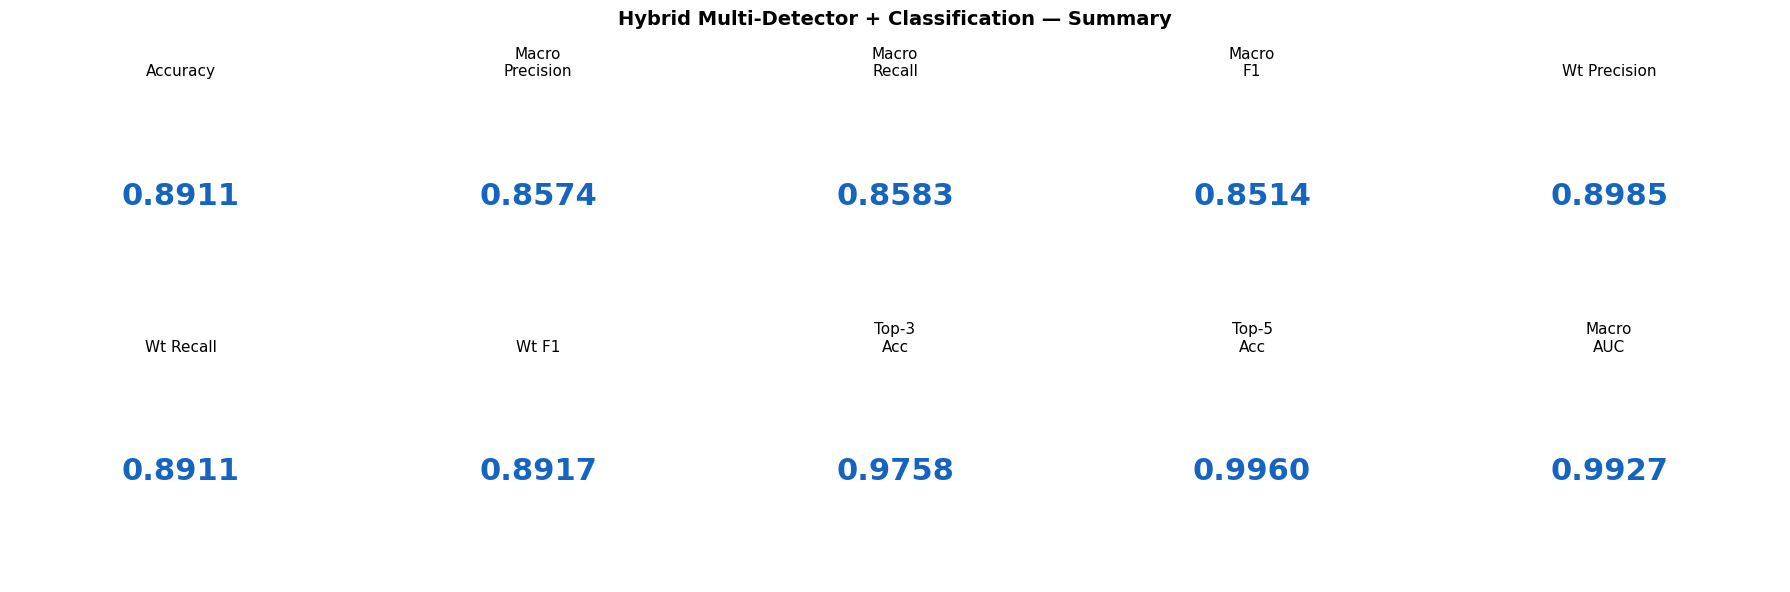

In [15]:
vals = [acc, prec_mac, rec_mac, f1_mac,
        prec_wt, rec_wt, f1_wt, top3, top5, macro_auc]
labs = ["Accuracy","Macro\nPrecision","Macro\nRecall","Macro\nF1",
        "Wt Precision","Wt Recall","Wt F1","Top-3\nAcc","Top-5\nAcc","Macro\nAUC"]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, v, lab in zip(axes.flat, vals, labs):
    colour = "#1565C0" if v >= 0.75 else "#B71C1C"
    ax.text(0.5, 0.5, f"{v:.4f}", ha="center", va="center",
            fontsize=22, fontweight="bold", color=colour,
            transform=ax.transAxes)
    ax.set_title(lab, fontsize=11)
    ax.set_facecolor("#F5F5F5"); ax.axis("off")
    for sp in ax.spines.values(): sp.set_visible(True); sp.set_color("#BDBDBD")

plt.suptitle("Hybrid Multi-Detector + Classification — Summary",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{RESULTS}/metrics_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

## 13 · Confusion Matrix

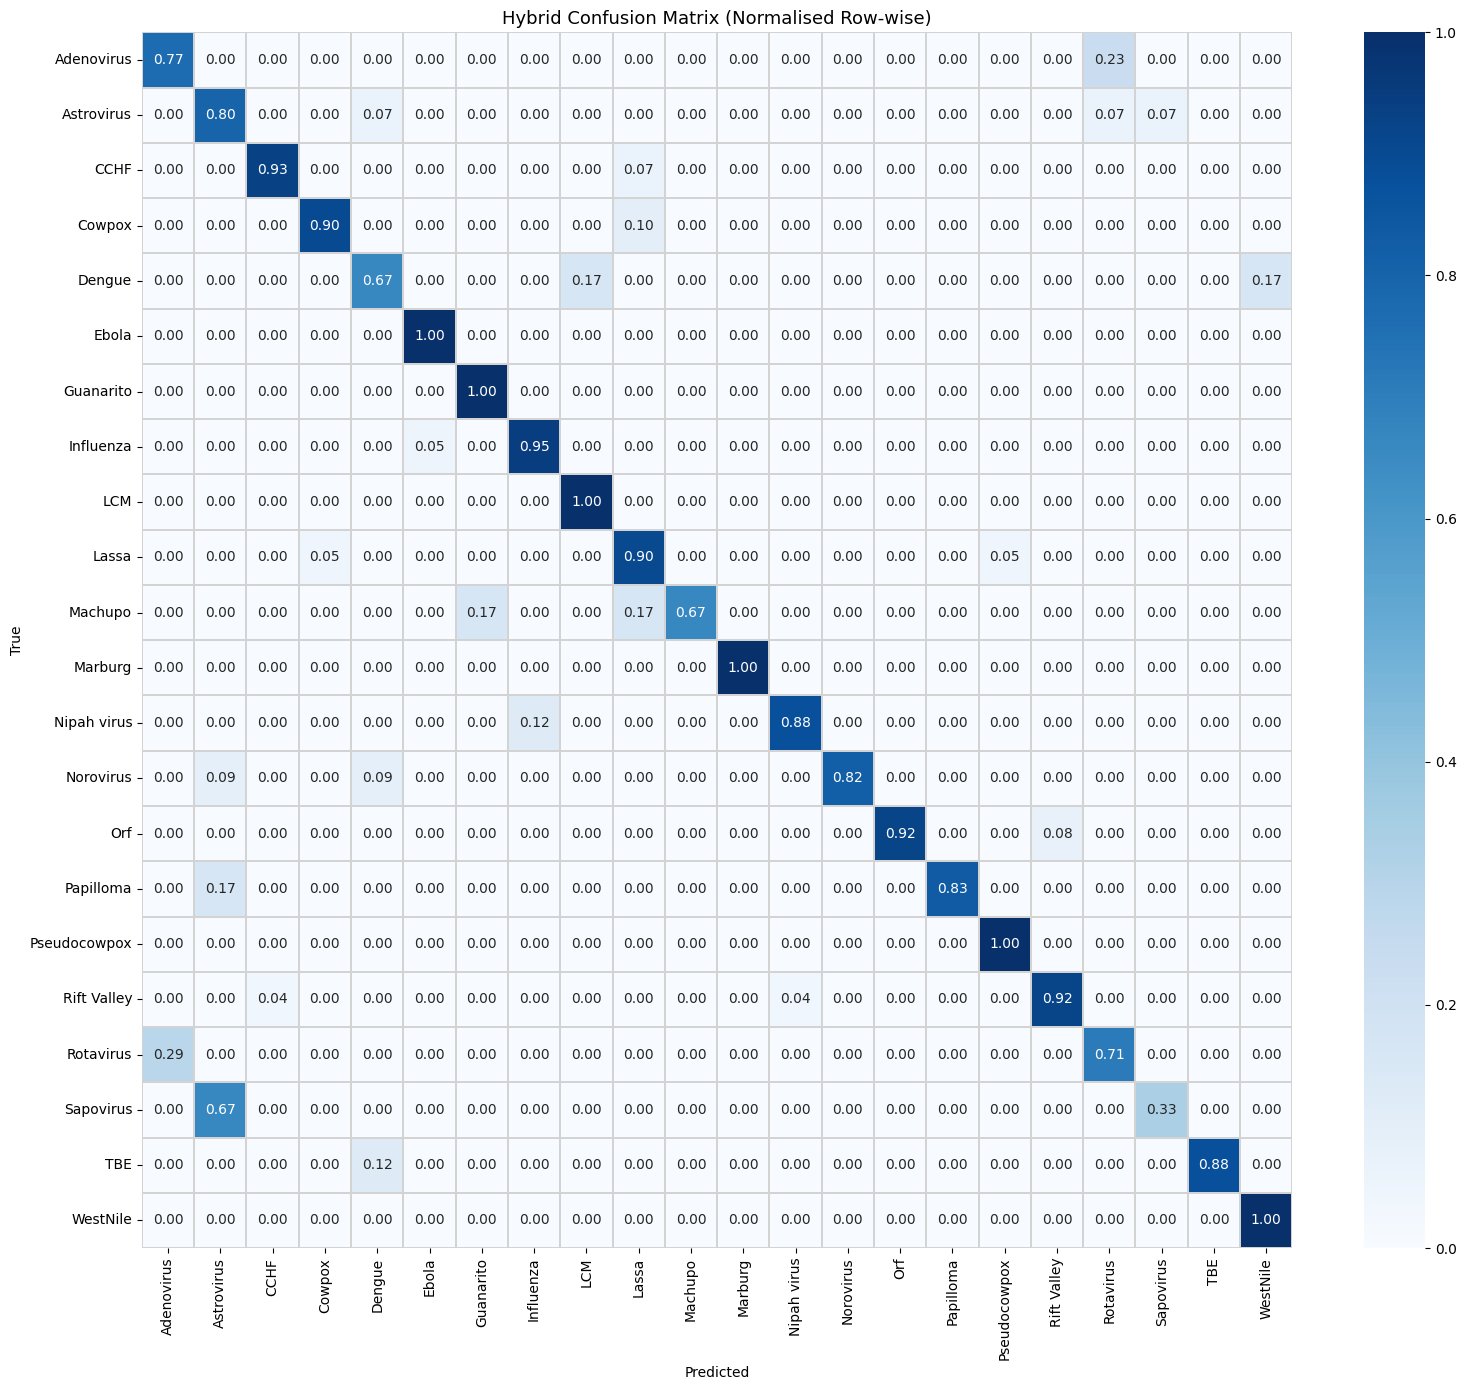

Saved confusion_matrix.png + .csv


In [16]:
cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, linecolor="lightgrey", ax=ax)
ax.set_title("Hybrid Confusion Matrix (Normalised Row-wise)", fontsize=13)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{RESULTS}/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
pd.DataFrame(cm, index=class_names, columns=class_names)\
    .to_csv(f"{RESULTS}/confusion_matrix.csv")
print("Saved confusion_matrix.png + .csv")

## 14 · Per-Class Classification Report

In [17]:
report = classification_report(y_true, y_pred,
                               target_names=class_names,
                               zero_division=0)
print(report)
with open(f"{RESULTS}/classification_report.txt", "w") as f:
    f.write(report)
print("Saved classification_report.txt")

              precision    recall  f1-score   support

  Adenovirus       0.83      0.77      0.80        13
  Astrovirus       0.75      0.80      0.77        15
        CCHF       0.93      0.93      0.93        15
      Cowpox       0.90      0.90      0.90        10
      Dengue       0.57      0.67      0.62         6
       Ebola       0.96      1.00      0.98        22
   Guanarito       0.80      1.00      0.89         4
   Influenza       0.95      0.95      0.95        19
         LCM       0.88      1.00      0.93         7
       Lassa       0.86      0.90      0.88        21
     Machupo       1.00      0.67      0.80         6
     Marburg       1.00      1.00      1.00        19
 Nipah virus       0.88      0.88      0.88         8
   Norovirus       1.00      0.82      0.90        11
         Orf       1.00      0.92      0.96        13
   Papilloma       1.00      0.83      0.91         6
Pseudocowpox       0.88      1.00      0.93         7
 Rift Valley       0.96    

## 15 · ROC Curves (All 22 Classes)

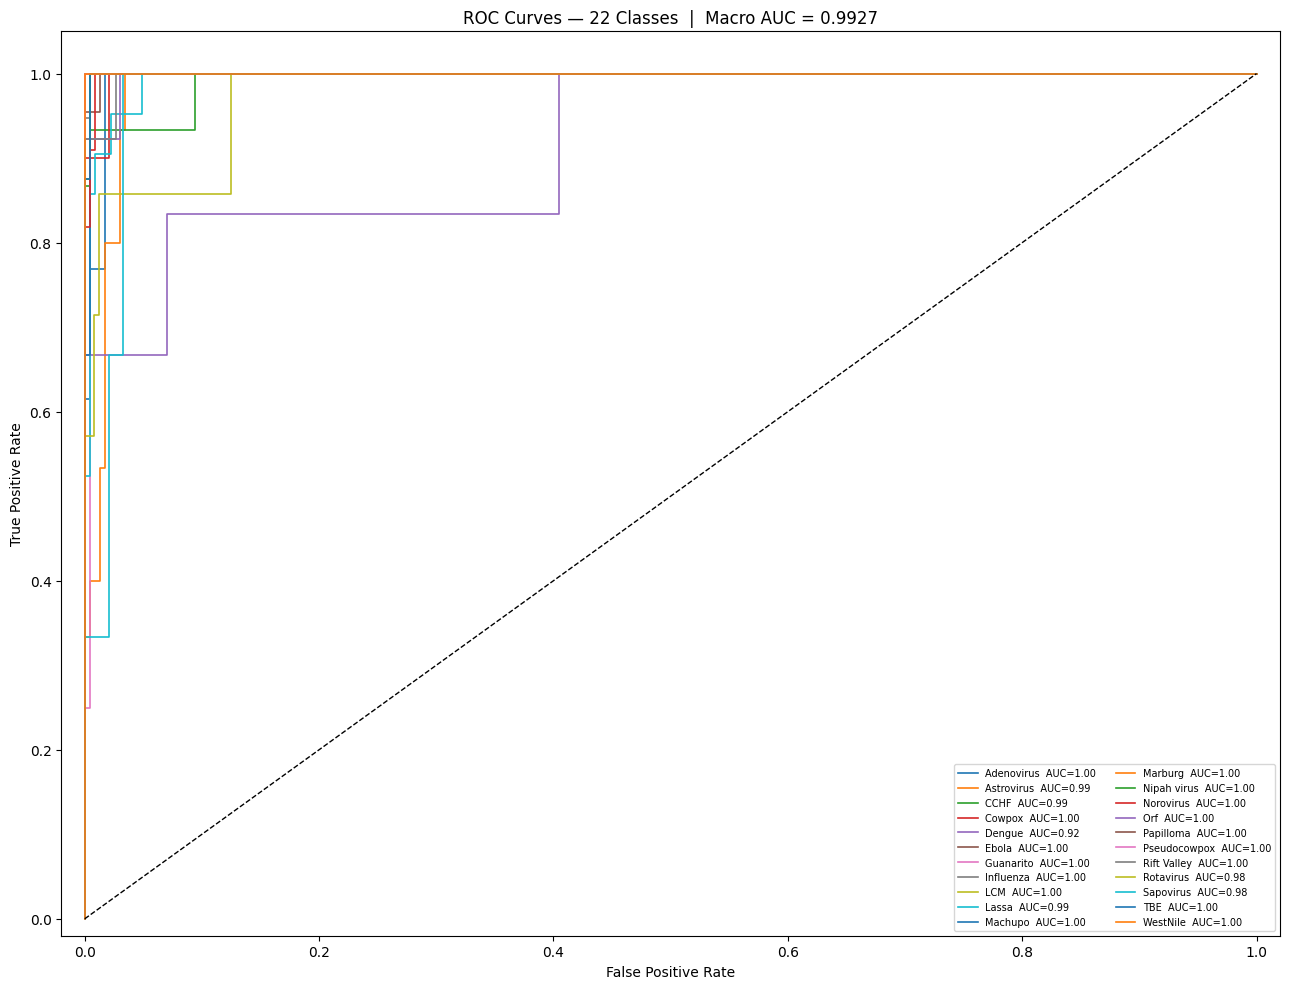

Saved roc_curves.png


In [18]:
fig, ax = plt.subplots(figsize=(13, 10))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    ax.plot(fpr, tpr, lw=1.2,
            label=f"{cls}  AUC={per_class_auc[i]:.2f}")
ax.plot([0,1],[0,1],"k--", lw=1)
ax.set(title=f"ROC Curves — 22 Classes  |  Macro AUC = {macro_auc:.4f}",
       xlabel="False Positive Rate", ylabel="True Positive Rate",
       xlim=[-0.02,1.02], ylim=[-0.02,1.05])
ax.legend(fontsize=7, ncol=2, loc="lower right")
plt.tight_layout()
plt.savefig(f"{RESULTS}/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved roc_curves.png")

## 16 · Precision-Recall Curves

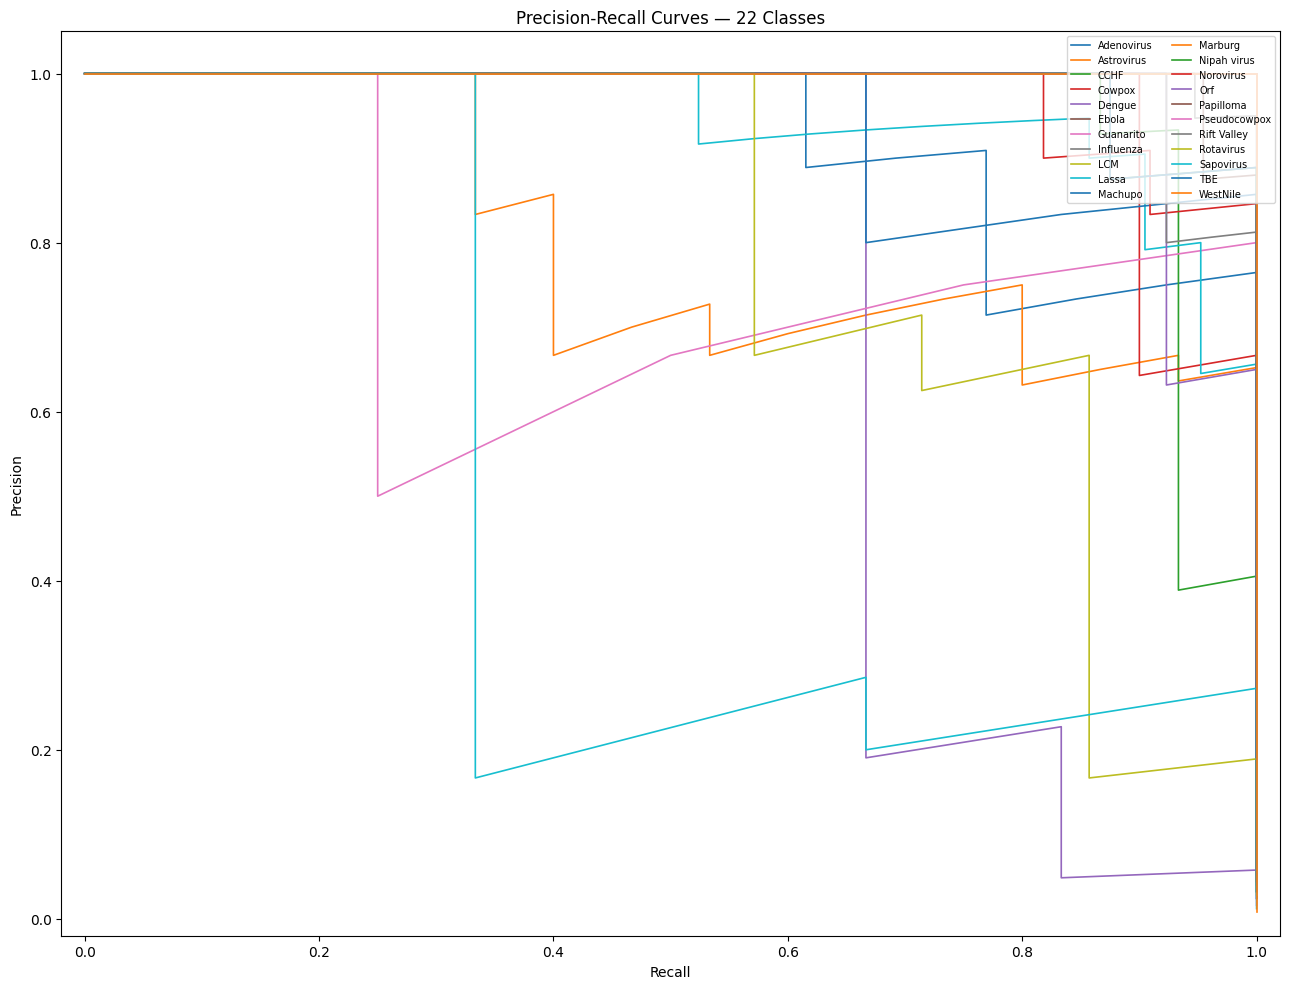

Saved pr_curves.png


In [19]:
fig, ax = plt.subplots(figsize=(13, 10))
for i, cls in enumerate(class_names):
    prec_, rec_, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    ax.plot(rec_, prec_, lw=1.2, label=cls)
ax.set(title="Precision-Recall Curves — 22 Classes",
       xlabel="Recall", ylabel="Precision", xlim=[-0.02,1.02], ylim=[-0.02,1.05])
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.savefig(f"{RESULTS}/pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved pr_curves.png")

## 17 · Per-Class AUC

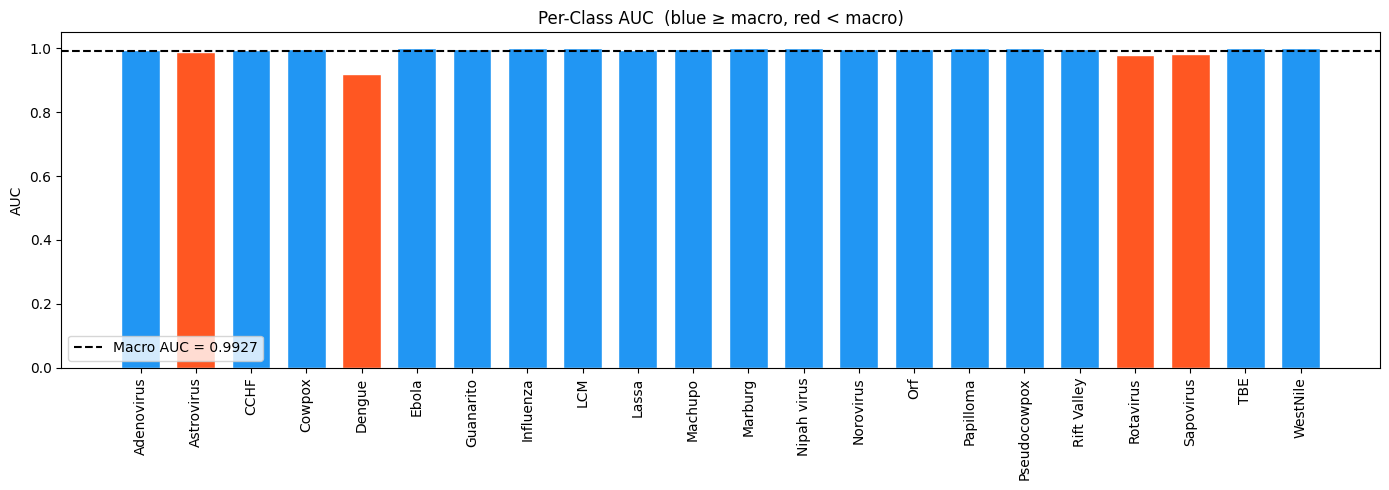

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#2196F3" if a >= macro_auc else "#FF5722" for a in per_class_auc]
ax.bar(class_names, per_class_auc, color=colors, edgecolor="white", width=0.7)
ax.axhline(macro_auc, color="black", linestyle="--", lw=1.5,
           label=f"Macro AUC = {macro_auc:.4f}")
ax.set(title="Per-Class AUC  (blue ≥ macro, red < macro)",
       ylabel="AUC", ylim=(0, 1.05))
plt.xticks(rotation=90); ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS}/per_class_auc.png", dpi=300, bbox_inches="tight")
plt.show()

## 18 · Per-Class F1 Score

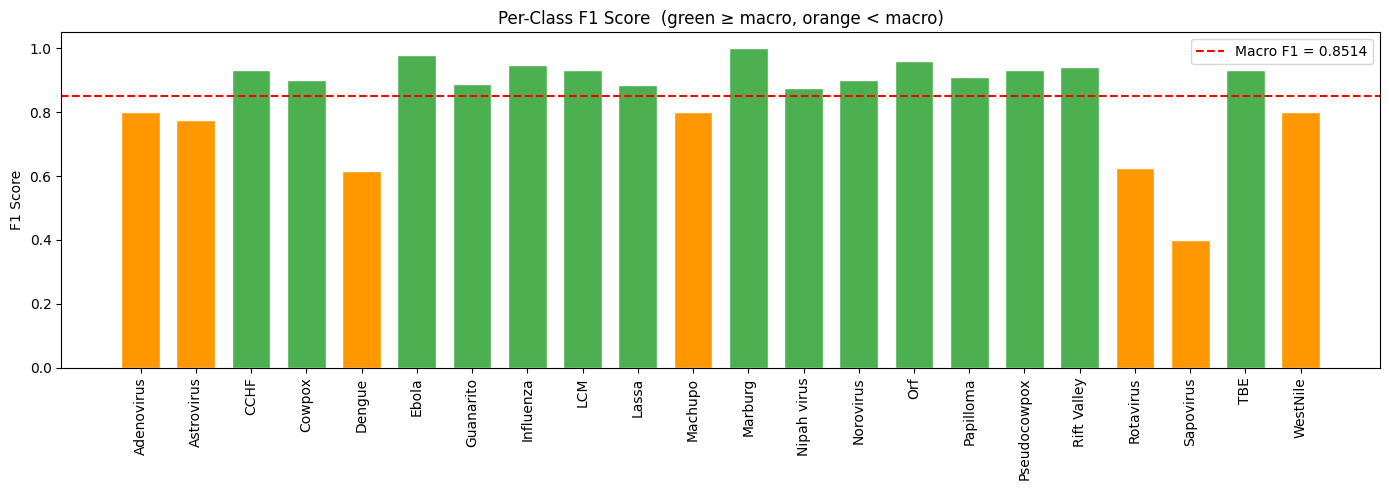

In [21]:
per_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
fig, ax = plt.subplots(figsize=(14, 5))
colors_f1 = ["#4CAF50" if v >= f1_mac else "#FF9800" for v in per_f1]
ax.bar(class_names, per_f1, color=colors_f1, edgecolor="white", width=0.7)
ax.axhline(f1_mac, color="red", linestyle="--", lw=1.5,
           label=f"Macro F1 = {f1_mac:.4f}")
ax.set(title="Per-Class F1 Score  (green ≥ macro, orange < macro)",
       ylabel="F1 Score", ylim=(0, 1.05))
plt.xticks(rotation=90); ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS}/per_class_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
print("\n" + "="*55)
print("  ✅  All results saved to:", RESULTS)
print("="*55)
print(f"  confusion_matrix.png/csv")
print(f"  classification_report.txt")
print(f"  roc_curves.png")
print(f"  pr_curves.png")
print(f"  per_class_auc.png")
print(f"  per_class_f1.png")
print(f"  metrics_dashboard.png")
print(f"  metrics_summary.csv")
print("="*55)


  ✅  All results saved to: results/hybrid_multi
  confusion_matrix.png/csv
  classification_report.txt
  roc_curves.png
  pr_curves.png
  per_class_auc.png
  per_class_f1.png
  metrics_dashboard.png
  metrics_summary.csv
